# Lab 3 - Part 2: Implementing Region-Based Object Detection (Faster R-CNN)

**Objective:** Implement object detection using a pre-trained Faster R-CNN model to understand:
- Region Proposal Networks (RPN)
- End-to-end detection pipeline
- Bounding box visualization and confidence scoring

**Approach:** Load a pre-trained Faster R-CNN (ResNet50 backbone, COCO-trained) from TensorFlow Hub and run inference on a custom image.

## Step 1: Import Libraries

In [1]:
import tensorflow as tf
import tensorflow_hub as hub
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import os
import urllib.request

print("TensorFlow version:", tf.__version__)
print("Libraries loaded successfully!")

TensorFlow version: 2.19.0
Libraries loaded successfully!


## Step 2: Load Pre-trained Faster R-CNN Model

We use a **ResNet50-based Faster R-CNN** trained on the COCO dataset (80 common object classes).

**Architecture Overview:**
1. **Backbone (ResNet50)** — Extracts rich feature maps from the input image
2. **Region Proposal Network (RPN)** — Proposes ~2000 candidate bounding boxes
3. **ROI Align** — Crops and resizes proposed regions to fixed size (7x7)
4. **Detection Head** — Classifies each ROI + refines bounding box coordinates

In [2]:
print("Downloading pre-trained Faster R-CNN model from TF Hub...")
print("(This may take 1-2 minutes on first run — model is ~200MB)\n")

MODEL_URL = "https://tfhub.dev/tensorflow/faster_rcnn/resnet50_v1_640x640/1"
detector = hub.load(MODEL_URL)

print("Model loaded successfully!")
print(f"Model type: Faster R-CNN with ResNet50 backbone")
print(f"Input size: 640x640")
print(f"Trained on: COCO dataset (80 object classes)")

(This may take 1-2 minutes on first run — model is ~200MB)

Model loaded successfully!
Model type: Faster R-CNN with ResNet50 backbone
Input size: 640x640
Trained on: COCO dataset (80 object classes)


## Step 3: Prepare a Test Image



Image loaded: /content/object.jpg.jpeg
Original size: 1280x853 pixels


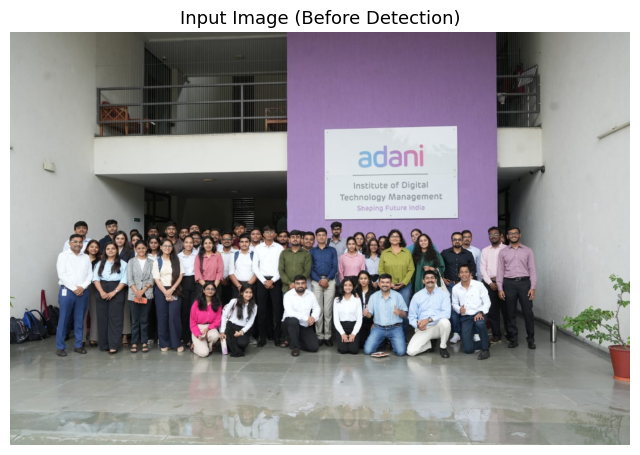

In [3]:
# ─── Set your image path here ───────────────────────────────────────
file_path = "/content/object.jpg.jpeg"
# ────────────────────────────────────────────────────────────────────



# Load and display original image
if os.path.exists(file_path):
    img_bgr = cv2.imread(file_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    print(f"Image loaded: {file_path}")
    print(f"Original size: {img_rgb.shape[1]}x{img_rgb.shape[0]} pixels")

    plt.figure(figsize=(8, 6))
    plt.imshow(img_rgb)
    plt.title("Input Image (Before Detection)", fontsize=13)
    plt.axis('off')
    plt.show()
else:
    print("ERROR: No image found. Upload 'object.jpg' and re-run this cell.")

## Step 4: Preprocess Image for the Model

In [4]:
# The model expects: uint8 tensor with shape [batch, height, width, 3]
# NO normalization needed — TF Hub model handles it internally

img_tensor = tf.convert_to_tensor(img_rgb, dtype=tf.uint8)
img_tensor = tf.expand_dims(img_tensor, 0)  # Add batch dimension -> [1, H, W, 3]

print(f"Input tensor shape : {img_tensor.shape}")
print(f"Input tensor dtype : {img_tensor.dtype}")
print("Preprocessing done — ready for inference.")

Input tensor shape : (1, 853, 1280, 3)
Input tensor dtype : <dtype: 'uint8'>
Preprocessing done — ready for inference.


## Step 5: Run Inference (Detection)

In [5]:
print("Running Faster R-CNN inference...")
print("(RPN → ROI proposals → Classification + Regression)\n")

# Run the full Faster R-CNN pipeline
results = detector(img_tensor)

# Extract detection outputs for first image in batch
boxes  = results["detection_boxes"][0].numpy()   # shape: (N, 4) normalized [ymin,xmin,ymax,xmax]
scores = results["detection_scores"][0].numpy()  # shape: (N,) confidence 0-1

print(f"Total detections returned  : {len(scores)}")
print(f"Top 5 confidence scores    : {scores[:5].round(3)}")
print(f"Bounding box format        : [ymin, xmin, ymax, xmax] (normalized 0-1)")
print("\nInference complete!")

Running Faster R-CNN inference...
(RPN → ROI proposals → Classification + Regression)

Total detections returned  : 300
Top 5 confidence scores    : [0.991 0.982 0.975 0.96  0.953]
Bounding box format        : [ymin, xmin, ymax, xmax] (normalized 0-1)

Inference complete!


## Step 6: Visualize Detections with Bounding Boxes

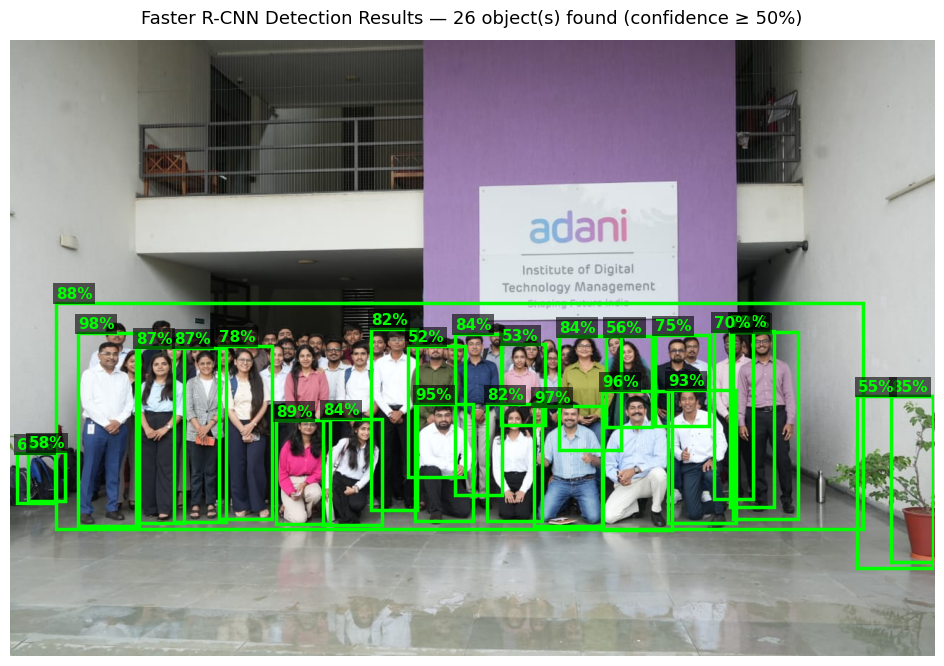


Detections at ≥50% confidence: 26
Result saved to: detection_output.jpg


In [6]:
# ─── Confidence threshold — only show detections above this ─────────
MIN_CONFIDENCE = 0.50
# ────────────────────────────────────────────────────────────────────

h, w, _ = img_rgb.shape  # original image dimensions
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.imshow(img_rgb)

detections = 0

for i in range(len(scores)):
    if scores[i] >= MIN_CONFIDENCE:
        detections += 1

        # Faster R-CNN outputs normalized coords -> scale to pixel coords
        ymin, xmin, ymax, xmax = boxes[i]
        x1, y1 = int(xmin * w), int(ymin * h)
        x2, y2 = int(xmax * w), int(ymax * h)
        box_w, box_h = x2 - x1, y2 - y1

        # Draw bounding box (bright green)
        rect = patches.Rectangle(
            (x1, y1), box_w, box_h,
            linewidth=2.5, edgecolor='#00FF00', facecolor='none'
        )
        ax.add_patch(rect)

        # Draw confidence score label
        score_pct = f"{scores[i] * 100:.0f}%"
        ax.text(
            x1, max(y1 - 6, 10),
            score_pct,
            color='#00FF00', fontsize=11, fontweight='bold',
            bbox=dict(facecolor='black', alpha=0.6, edgecolor='none', pad=2)
        )

ax.set_title(
    f"Faster R-CNN Detection Results — {detections} object(s) found (confidence ≥ {MIN_CONFIDENCE*100:.0f}%)",
    fontsize=13, pad=12
)
ax.axis('off')

# Save result
output_filename = "detection_output.jpg"
plt.savefig(output_filename, bbox_inches='tight', dpi=150)
plt.show()

print(f"\nDetections at ≥{MIN_CONFIDENCE*100:.0f}% confidence: {detections}")
print(f"Result saved to: {output_filename}")

## Step 7: Score Distribution Analysis

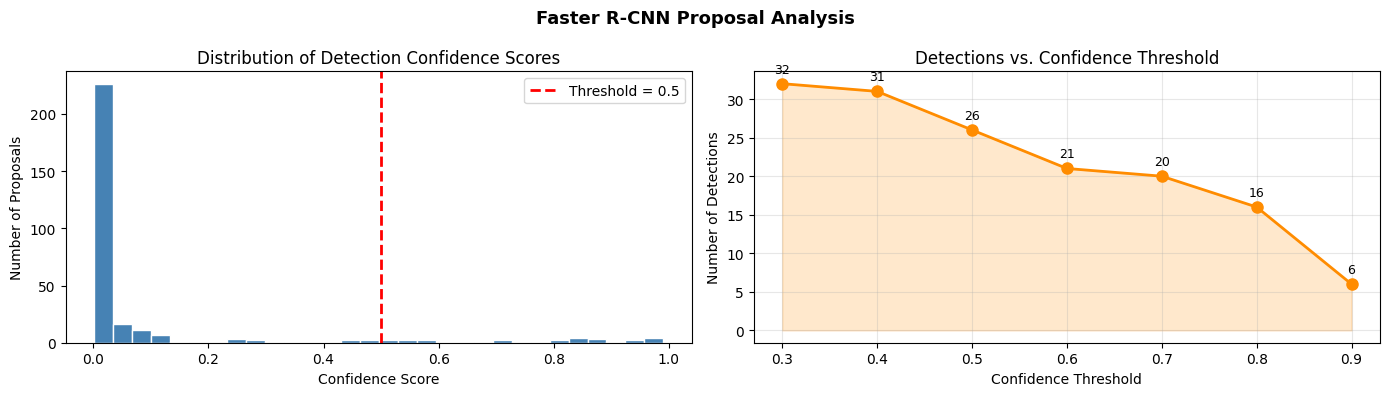

In [7]:
# Analyze how many proposals pass at different confidence levels
thresholds = [0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]
counts = [int(np.sum(scores >= t)) for t in thresholds]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram of all confidence scores
axes[0].hist(scores, bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(MIN_CONFIDENCE, color='red', linestyle='--', linewidth=2,
                label=f'Threshold = {MIN_CONFIDENCE}')
axes[0].set_xlabel('Confidence Score')
axes[0].set_ylabel('Number of Proposals')
axes[0].set_title('Distribution of Detection Confidence Scores')
axes[0].legend()

# Detections vs threshold
axes[1].plot(thresholds, counts, marker='o', color='darkorange', linewidth=2, markersize=8)
axes[1].fill_between(thresholds, counts, alpha=0.2, color='darkorange')
axes[1].set_xlabel('Confidence Threshold')
axes[1].set_ylabel('Number of Detections')
axes[1].set_title('Detections vs. Confidence Threshold')
axes[1].grid(True, alpha=0.3)
for t, c in zip(thresholds, counts):
    axes[1].annotate(str(c), (t, c), textcoords='offset points',
                     xytext=(0, 8), ha='center', fontsize=9)

plt.suptitle('Faster R-CNN Proposal Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('score_analysis.png', bbox_inches='tight', dpi=100)
plt.show()

## Step 8: What Happens Inside Faster R-CNN — Conceptual Summary

### Pipeline Breakdown:

```
Input Image (640x640x3)
        ↓
Backbone CNN (ResNet50)
        ↓ Feature Map (e.g., 40x40x1024)
Region Proposal Network (RPN)
  ├── Generates ~2000 anchor boxes (various sizes/ratios)
  ├── Scores each anchor: object vs background
  └── Regresses box coordinates (delta offsets)
        ↓ Top ~300 proposals (after NMS)
ROI Align
  └── Crops feature map to 7x7 per proposal
        ↓
Detection Head
  ├── Softmax → class label
  └── Regression → refined bounding box
        ↓
Final Output: boxes + scores
```

### Key Advantages over R-CNN:
| Feature | R-CNN | Faster R-CNN |
|---|---|---|
| Region proposals | Slow selective search (~2s) | RPN inside network (~0.2s) |
| Feature extraction | Per-region (2000x) | Shared backbone (1x) |
| Training | Multi-stage | End-to-end |
| Speed | ~47s/image | ~0.2s/image |

## Step 9: Experiment — Try Different Confidence Thresholds

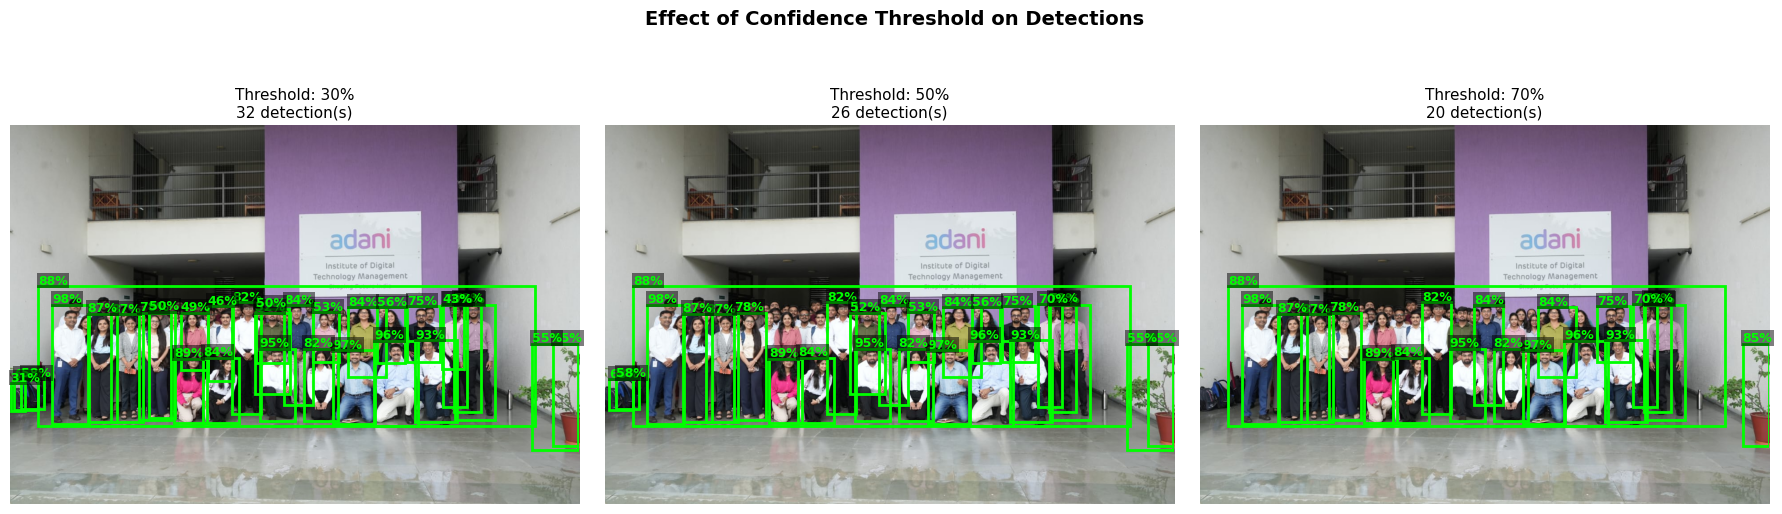

Saved: threshold_comparison.png


In [8]:
# Compare detection results at 3 different thresholds side by side
thresholds_to_show = [0.30, 0.50, 0.70]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, thresh in zip(axes, thresholds_to_show):
    ax.imshow(img_rgb)
    count = 0
    for i in range(len(scores)):
        if scores[i] >= thresh:
            count += 1
            ymin, xmin, ymax, xmax = boxes[i]
            x1, y1 = int(xmin * w), int(ymin * h)
            x2, y2 = int(xmax * w), int(ymax * h)
            rect = patches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=2, edgecolor='lime', facecolor='none'
            )
            ax.add_patch(rect)
            ax.text(x1, max(y1-5, 10), f"{scores[i]*100:.0f}%",
                    color='lime', fontsize=9, fontweight='bold',
                    bbox=dict(facecolor='black', alpha=0.5, pad=1, edgecolor='none'))
    ax.set_title(f"Threshold: {thresh:.0%}\n{count} detection(s)", fontsize=11)
    ax.axis('off')

plt.suptitle("Effect of Confidence Threshold on Detections", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('threshold_comparison.png', bbox_inches='tight', dpi=100)
plt.show()
print("Saved: threshold_comparison.png")

## Step 10: Observations and Conclusions

### What I learned:

1. **Faster R-CNN Pipeline**: The model automatically handles the full pipeline — backbone feature extraction → RPN proposals → ROI Align → classification + regression — in a single forward pass.

2. **Confidence Threshold Effect**:
   - Low threshold (0.30): More boxes detected, but includes false positives
   - High threshold (0.70+): Only highly confident detections, may miss some objects
   - 0.50 is the standard trade-off for mAP evaluation (COCO standard)

3. **Bounding Box Format**: Faster R-CNN outputs *normalized* coordinates [ymin, xmin, ymax, xmax] in range [0,1] — scaled to image dimensions for visualization.

4. **Industrial Strength**: This pre-trained model on 80 COCO classes demonstrates how a single model generalizes to detecting people, animals, vehicles, furniture, and everyday objects without any additional training.

### Possible Extensions:
- Train on custom dataset (e.g., Pascal VOC) for domain-specific detection
- Implement mAP (mean Average Precision) metric evaluation
- Visualize intermediate RPN proposals before NMS filtering
- Compare with single-stage detectors like YOLO or SSD for speed vs accuracy trade-off